# ITO5201 – Assessment 1: Section 4
## Logistic Regression versus Bayes Classifier
**Student:** Johannes Coetzee  
**Student Number:** 36384852

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import zero_one_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

---
## Question 7 – Discriminative vs Generative Models
### Bayes Classifier (from Activity 3.3)

Copy the Bayes classifier implementation from Activity 3.3 below. Include all three variants:
- Naive Bayes (no shared covariance)
- Full covariance, shared
- Full covariance, not shared

In [2]:
# Source: Adapted from Activity 3.3 (Modules/3/Activities/Activity.3.3_solutions.ipynb)
class MyBayesianClassifier:

    """
    A Bayesian classifier that can handle both shared and class-specific covariance matrices, as well as conditional independence assumptions.
    __init__ method initializes the classifier with options for shared covariance and conditional independence.
    - shared_cov: If True, uses a shared covariance matrix for all classes; if False, uses class-specific covariance matrices.
    - cond_ind: If True, assumes conditional independence of features given the class; if False, uses the full covariance matrix for each class.
    fit method estimates the parameters of the model (means and covariances) based on the training data.
    - x: Input features (numpy array of shape [n_samples, n_features]).
    - y: Class labels (numpy array of shape [n_samples]).
    predict_proba method computes the posterior probabilities for each class given the input features.
    - x: Input features (numpy array of shape [n_samples, n_features]).
    predict method predicts the class labels for the input features based on the highest posterior probability.
    - x: Input features (numpy array of shape [n_samples, n_features]).
    decision_function method computes the log-odds for binary classification or log-likelihood ratios for multi-class classification.
    - x: Input features (numpy array of shape [n_samples, n_features]).
    generate method generates synthetic samples from the estimated class-conditional distributions.
    - n: Number of samples to generate.
    - c: Class label for which to generate samples.
    - random_state: Optional random state for reproducibility.

    Numpy functions used:
    - np.unique: Finds the unique elements of an array.
    - np.zeros: Creates an array filled with zeros.
    - np.fill_diagonal: Fills the diagonal of an array with a specified value.
    - np.cov: Computes the covariance matrix of an array.
    - np.moveaxis: Moves axes of an array to new positions.
    - np.argmax: Returns the indices of the maximum values along an axis.
    - np.divide: Performs element-wise division of arrays.
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.unique.html
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.zeros.html
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.fill_diagonal.html
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.cov.html
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.moveaxis.html
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.argmax.html
    """


    def __init__(self, shared_cov=True, cond_ind=True):
        self.shared_cov = shared_cov
        self.cond_ind   = cond_ind

    def fit(self, x, y):
        self.classes_, class_counts = np.unique(y, return_counts=True)
        self.n_, self.p_ = x.shape
        self.k_ = len(self.classes_)
        self.cond_means_ = np.zeros((self.k_, self.p_))
        self.cond_covs_  = np.zeros((self.k_, self.p_, self.p_))

        self.class_priors_ = class_counts / len(y)
        for c in range(self.k_):
            mask = y == self.classes_[c]
            self.cond_means_[c] = x[mask].mean(axis=0)
            if self.cond_ind:
                np.fill_diagonal(self.cond_covs_[c], x[mask].var(axis=0))
            else:
                self.cond_covs_[c] = np.cov(x[mask].T, bias=True)

        if self.shared_cov:
            shared = np.moveaxis(self.cond_covs_, 0, -1).dot(self.class_priors_)
            self.cond_covs_[:] = shared

        return self

    def predict_proba(self, x):
        m = len(x)
        cond_probs = np.zeros((m, self.k_))
        for c in range(self.k_):
            cond_probs[:, c] = multivariate_normal.pdf(
                x, self.cond_means_[c], self.cond_covs_[c], allow_singular=True
            )
        marginal_probs = cond_probs @ self.class_priors_
        probs = np.divide(
            (cond_probs * self.class_priors_).T,
            marginal_probs,
            where=marginal_probs > 0,
            out=np.zeros((self.k_, m))
        ).T
        return probs

    def predict(self, x):
        return self.classes_[np.argmax(self.predict_proba(x), axis=1)]

    def decision_function(self, x):
        probs = self.predict_proba(x)
        if self.k_ == 2:
            return np.log(probs[:, 1] / np.maximum(probs[:, 0], 1e-300))
        else:
            res = np.zeros((len(x), self.k_))
            for c in range(self.k_):
                res[:, c] = np.log(probs[:, c] / np.maximum(1 - probs[:, c], 1e-300))
            return res

    def generate(self, n, c, random_state=None):
        return multivariate_normal.rvs(
            self.cond_means_[c], self.cond_covs_[c], size=n, random_state=random_state
        )

### Q7.I – Load Breast Cancer Dataset and Fit All Models

In [3]:
# PREPROCESSING: Load the breast cancer dataset and split into train/test sets
"""
This cell loads the breast cancer dataset and splits it into training and testing sets. 
The training set consists of 80% of the data, while the testing set consists of the remaining 20%. 
The data is shuffled before splitting to ensure randomness.

Logistic Regression uses the same StandardScaler pipeline as the learning-curve
experiment in Q7.II, so the two sections evaluate identical models (see Q7.II
cell docstring for the scaling rationale).

SKLearn functions used:
- load_breast_cancer: Loads the breast cancer dataset from sklearn.datasets.
- train_test_split: Splits arrays or matrices into random train and test subsets.
Ref: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
Ref: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

"""

RANDOM_BREAST_CANCER = True  # Set to True for a fixed, reproducible split (random_state=42); False for a different split every run
random_state = 42 if RANDOM_BREAST_CANCER else None

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, shuffle=True, random_state=random_state
)

# Instantiate all 4 classifiers
Q7_models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=10_000)),
    'Naive Bayes (BC)': MyBayesianClassifier(shared_cov=False, cond_ind=True),
    'BC Shared Covariance': MyBayesianClassifier(shared_cov=True, cond_ind=False),
    'BC Non-Shared Covariance': MyBayesianClassifier(shared_cov=False, cond_ind=False)
}


In [4]:
"""
This cell evaluates the performance of different classifiers on the breast cancer dataset.
The classifiers are trained on the training set and evaluated on both the training and testing sets.
The accuracy of each classifier is printed in a formatted table.

Numpy functions used:
- np.mean: Computes the mean of array elements along a specified axis.
Ref: https://numpy.org/doc/stable/reference/generated/numpy.mean.html
"""

print(f"{'Model':<25}  {'Train acc':>10}  {'Test acc':>10}")
print("-" * 50)
for name, model in Q7_models.items():
    model.fit(X_train, y_train)
    train_acc = np.mean(model.predict(X_train) == y_train)
    test_acc  = np.mean(model.predict(X_test)  == y_test)
    print(f"{name:<25}  {train_acc:>10.4f}  {test_acc:>10.4f}")

Model                       Train acc    Test acc
--------------------------------------------------
Logistic Regression            0.9868      0.9737
Naive Bayes (BC)               0.9275      0.9561
BC Shared Covariance           0.9626      0.9561
BC Non-Shared Covariance       0.9429      0.9211


**Result:** Logistic Regression performs best on both train (0.9868) and test (0.9737) accuracy. The Bayes classifier variants trail it on the test set — Naive Bayes and the shared-covariance variant are tied at 0.9561, while the non-shared-covariance variant is weakest at 0.9211, consistent with it having by far the most parameters to estimate (see Q7.IV).

### Q7.II – Learning Curve Experiment: N = 5, 10, ..., 500

In [5]:
# EXECUTION: Run the experiment for different training set sizes and record the results

"""
This cell runs an experiment to evaluate the performance of different classifiers on the breast cancer dataset for varying training set sizes.
The experiment iterates over a range of training sizes, from 5 to 500 in increments of 5, 
and performs multiple repetitions for each size to obtain average performance metrics.
The classifiers are trained on subsets of the training data and evaluated on both the training and testing sets.
The results are stored in a dictionary for further analysis or visualization.

Feature scaling: LogisticRegression is wrapped in a StandardScaler pipeline because
lbfgs converges slowly on features with very different scales (thousands of iterations
unscaled vs ~40 scaled).
Regularisation: sklearn's default L2 penalty (C=1.0) is kept. The dataset is
close to linearly separable, so unregularised maximum-likelihood logistic
regression drives the training error to zero and generalises worse; the mild
default penalty stabilises the fits. The regularised variant of logistic
regression is the one developed in Activity 3.2
(Modules/3/Activities/Activity.3.2_solutions.ipynb).
Reproducibility: each (N, repetition) subsample uses a fixed random_state so the
experiment produces identical results on every run; all models still share the
same training set within a given repetition.
Ref: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
Ref: https://scikit-learn.org/stable/modules/preprocessing.html
Ref: https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html
"""

training_sizes = list(range(5, 505, 5)) # Training sizes to evaluate, from 5 to 500 in increments of 5
n_reps = 10 # Number of repetitions for each training size to obtain average performance metrics

model_factories = {
    'Logistic Regression':    lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=10_000)),
    'Naive Bayes (BC)':       lambda: MyBayesianClassifier(shared_cov=False, cond_ind=True),
    'BC Shared Covariance':   lambda: MyBayesianClassifier(shared_cov=True,  cond_ind=False),
    'BC Non-Shared Covariance': lambda: MyBayesianClassifier(shared_cov=False, cond_ind=False),
}

valid_sizes = [N for N in training_sizes if N < len(X_train)]
results = {name: {'train': [], 'test': []} for name in model_factories}

for N in valid_sizes:
    rep_train = {name: [] for name in model_factories}
    rep_test  = {name: [] for name in model_factories}
    for rep in range(n_reps):
        # stratify=y_train guarantees both classes appear in every subsample;
        # without it, small N draws can produce a single-class split that crashes LogisticRegression.
        # random_state=N*100+rep gives every (N, rep) pair its own fixed, collision-free seed.
        X_tr, _, y_tr, _ = train_test_split(
            X_train, y_train, train_size=N, shuffle=True, stratify=y_train,
            random_state=N * 100 + rep
        )
        for name, factory in model_factories.items():
            m = factory()
            m.fit(X_tr, y_tr)
            rep_train[name].append(zero_one_loss(y_tr,   m.predict(X_tr)))
            rep_test[name].append( zero_one_loss(y_test, m.predict(X_test)))
    for name in model_factories:
        results[name]['train'].append(np.mean(rep_train[name]))
        results[name]['test'].append(np.mean(rep_test[name]))


### Q7.III – Plot Learning Curves

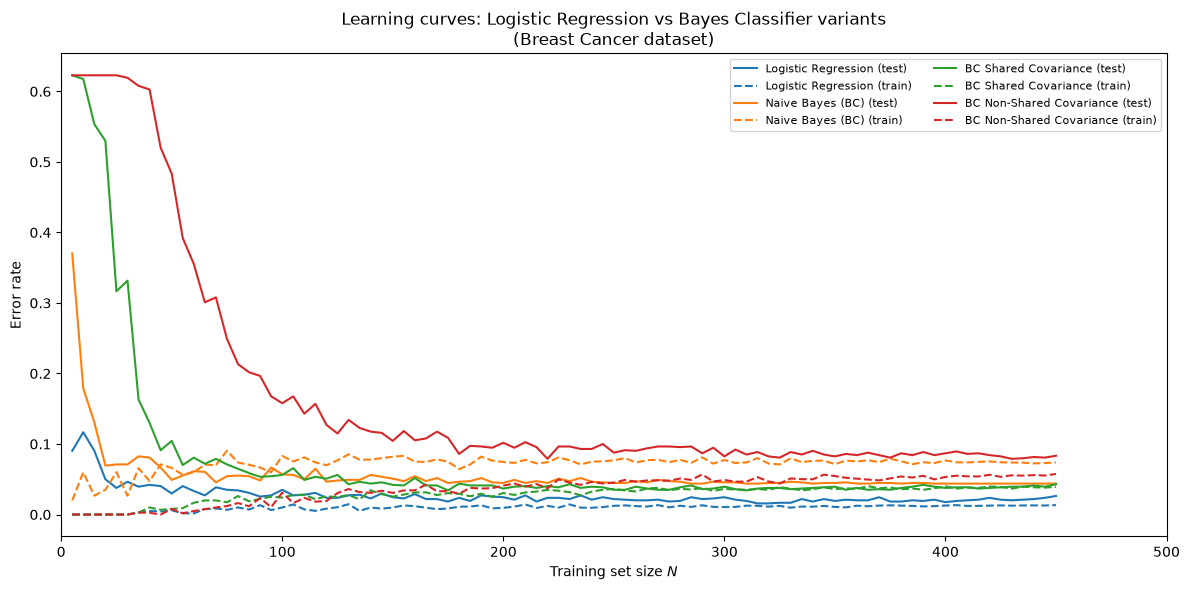

In [6]:
# PLOTTING: Plot Logistic Regression vs Bayes Classifier variants learning curves (mean train/test error rates vs training set size)

"""
This cell plots the mean training and testing error rates against the training set sizes for different classifiers.
The plot provides a visual representation of the learning curves for each classifier, allowing for comparison of their performance as the training set size increases.

"""

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, ax = plt.subplots(figsize=(12, 6))
for (name, data_r), color in zip(results.items(), colors):
    ax.plot(valid_sizes, data_r['test'],  color=color, linestyle='-',  label=f'{name} (test)')
    ax.plot(valid_sizes, data_r['train'], color=color, linestyle='--', label=f'{name} (train)')

ax.set_xlabel('Training set size $N$')
ax.set_ylabel('Error rate')
ax.set_title('Learning curves: Logistic Regression vs Bayes Classifier variants\n(Breast Cancer dataset)')
ax.set_xbound(0, 500) 
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Q7.IV – Discussion
#### 1. Effect of increasing training data on each classifier

As $N$ increases, every classifier's test error decreases and its train error increases, following the classic learning curve pattern driven by the bias–variance trade-off.

* **Logistic Regression:** At small $N$ the train error is near zero (high variance — the model memorises the few training points) while the test error is high. As $N$ grows, train error rises and test error falls rapidly, and the two converge toward a low asymptote. LR ultimately achieves the lowest test error because it directly models the decision boundary without making assumptions about $p(\mathbf{x})$.

* **Naive Bayes:** Train error is higher at small $N$ than LR (NB is less flexible; its inductive bias prevents memorisation). However, test error drops quickly and reaches a low value early — NB benefits from having fewer parameters to estimate. At large $N$ the test error levels off above LR because the conditional independence assumption $p(\mathbf{x}|c) = \prod_j p(x_j|c)$ is violated in practice: the 30 breast cancer features are correlated, so the model is misspecified.

* **BC Shared Covariance:** Slower start than NB — its single full $p \times p$ covariance (≈525 parameters in total) needs more data to estimate, so its test error stays near chance level until $N \approx 20$ and only catches NB around $N \approx 130$. Beyond that point it runs level with or slightly ahead of NB (test error ≈0.037 vs ≈0.045 at $N = 200$; ≈0.043 vs ≈0.044 at $N = 450$): once the covariance is estimable, modelling the feature correlations that NB ignores compensates for the extra parameters, while the shared-covariance constraint still keeps the variance under control.

* **BC Non-Shared Covariance:** The most parameter-heavy variant (two full $30 \times 30$ covariance matrices, ≈990 parameters). At small $N$ the per-class covariance estimates are singular (guaranteed whenever a class has fewer than $p = 30$ samples), and the classifier degenerates to near-constant predictions — its flat test error of ≈0.62 for $N \lesssim 40$ is exactly the majority-class proportion of the test set. It improves steadily once both classes have enough samples, and would converge to the Bayes-optimal solution if the class-conditional distributions were truly Gaussian; in practice it remains the worst of the four models across the whole plotted range (test error ≈0.10 at $N = 200$, still ≈0.08 at $N = 450$).

#### 2. Which classifier is best suited for small vs large training sets?

* **Small $N$:** In this experiment **Logistic Regression is best at every training size**, including the smallest (mean test error ≈0.09 at $N = 5$ vs ≈0.37 for Naive Bayes). This is consistent with the parameter counts in part 3: LR has by far the fewest free parameters (31), so the "simpler model wins when data is scarce" argument favours it here too — and sklearn's default mild L2 regularisation further stabilises the small-$N$ fits. **Among the generative variants**, Naive Bayes is clearly the best suited to small $N$: its independence assumption acts as a regulariser that keeps its 120 parameters estimable while the full-covariance variants are still producing singular, degenerate estimates. The classic small-sample advantage of NB over LR (Ng & Jordan) concerns how quickly each model reaches its *own* asymptotic error; here LR's 31 parameters are already well estimated by $N \approx 10$–$20$, so NB never overtakes it.

* **Large $N$:** Logistic Regression is again best suited (test error ≈0.026 at $N = 450$, vs ≈0.043–0.044 for the best generative variants, BC shared covariance and Naive Bayes). With enough data all models estimate their parameters reliably, but the generative models remain limited by their distributional assumptions (Gaussianity, independence, shared covariance), which do not hold exactly. Because LR models $p(y \mid \mathbf{x})$ directly without spending capacity on modelling $p(\mathbf{x})$, it uses its parameters more efficiently and achieves the lowest asymptotic error rate.

#### 3. Justify observations via model assumptions and parameter count

The key driver of the observed behaviour is the **number of free parameters** each model must estimate and the **assumptions** it makes to reduce that count.

For the breast cancer dataset ($p = 30$ features, $K = 2$ classes):

| Model | Parameters to estimate | Notes |
|---|---|---|
| Logistic Regression | $p + 1 = 31$ | weight vector + intercept |
| Naive Bayes | $2Kp = 120$ | $K$ mean vectors + $K$ diagonal covariances |
| BC Shared Cov | $Kp + \frac{p(p+1)}{2} \approx 525$ | $K$ means + one full symmetric covariance |
| BC Non-Shared Cov | $Kp + K\frac{p(p+1)}{2} \approx 990$ | $K$ means + $K$ full covariances |

**Why the small-$N$ ordering follows the parameter count:** At $N = 5$ the observed test errors order exactly as the parameter counts predict: LR (≈0.09) < NB (≈0.37) < BC shared ≈ BC non-shared (≈0.62, chance level). With 990 parameters, BC non-shared is vastly underdetermined — its covariance matrices are singular and its predictions degenerate. NB's independence assumption collapses each covariance to a diagonal, cutting the count to 120, so it is the first generative model to produce sensible estimates. But LR, with only 31 parameters, is more economical still, which is why it wins outright at every sample size in this experiment rather than only at large $N$.

**Why LR dominates at large $N$:** LR is a discriminative model — it directly learns the boundary $p(y \mid \mathbf{x})$ using only $p + 1$ parameters. It does not model the marginal distribution $p(\mathbf{x})$, which is irrelevant for classification and wastes capacity in generative models. As $N \to \infty$, LR's decision surface converges to a good classifier, while the generative models are constrained by their distributional assumptions (Gaussianity, shared or independent covariances) that may not hold exactly. This is consistent with the theoretical result of Ng and Jordan (2002), who showed that for Gaussian class conditionals, NB converges to its asymptotic error faster than LR but LR achieves a lower asymptotic error when the independence assumption is violated.